# Phishing Detection - Exploratory Data Analysis

This notebook performs a general EDA on the **URL-Phish Dataset** covering:
1. Data loading & basic info
2. Missing values analysis
3. Class imbalance check
4. Feature skewness analysis
5. Summary statistics & distributions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Load the dataset
df = pd.read_csv(r'G:/My Drive/URL-Phish_Dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"Total samples: {df.shape[0]:,}")
print(f"Total features: {df.shape[1]}")

Dataset shape: (116600, 26)
Total samples: 116,600
Total features: 26


In [18]:
df.columns

Index(['url', 'url_len', 'dom', 'dom_len', 'is_ip', 'tld', 'tld_len',
       'subdom_cnt', 'letter_cnt', 'digit_cnt', 'special_cnt', 'eq_cnt',
       'qm_cnt', 'amp_cnt', 'dot_cnt', 'dash_cnt', 'under_cnt', 'letter_ratio',
       'digit_ratio', 'spec_ratio', 'is_https', 'slash_cnt', 'entropy',
       'path_len', 'query_len', 'label'],
      dtype='str')

## 1. Basic Data Overview
Let's look at the first few rows, data types, and basic info.

In [2]:
# Preview the first 5 rows
df.head()

,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,24,rmit.edu.au,11,0,edu.au,6,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,26,latrobe.edu.au,14,0,edu.au,6,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,23,cqu.edu.au,10,0,edu.au,6,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,19,bond.edu.au,11,0,edu.au,6,0,13,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,22,csu.edu.au,10,0,edu.au,6,1,15,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 116600 entries, 0 to 116599
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   url           116600 non-null  str    
 1   url_len       116600 non-null  int64  
 2   dom           116600 non-null  str    
 3   dom_len       116600 non-null  int64  
 4   is_ip         116600 non-null  int64  
 5   tld           116586 non-null  str    
 6   tld_len       116600 non-null  int64  
 7   subdom_cnt    116600 non-null  int64  
 8   letter_cnt    116600 non-null  int64  
 9   digit_cnt     116600 non-null  int64  
 10  special_cnt   116600 non-null  int64  
 11  eq_cnt        116600 non-null  int64  
 12  qm_cnt        116600 non-null  int64  
 13  amp_cnt       116600 non-null  int64  
 14  dot_cnt       116600 non-null  int64  
 15  dash_cnt      116600 non-null  int64  
 16  under_cnt     116600 non-null  int64  
 17  letter_ratio  116600 non-null  float64
 18  digit_ratio   1

In [5]:
# Descriptive statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
url_len,116600.0,32.952521,29.369989,12.000000,22.000000,27.000000,34.000000,1202.000000
dom_len,116600.0,12.845763,5.140745,4.000000,9.000000,11.000000,16.000000,62.000000
is_ip,116600.0,0.000111,0.010558,0.000000,0.000000,0.000000,0.000000,1.000000
tld_len,116600.0,3.320223,1.418215,0.000000,2.000000,3.000000,3.000000,22.000000
subdom_cnt,116600.0,0.845669,0.480620,0.000000,1.000000,1.000000,1.000000,7.000000
letter_cnt,116600.0,25.006810,22.396380,4.000000,16.000000,20.000000,27.000000,1037.000000
digit_cnt,116600.0,0.943988,5.947690,0.000000,0.000000,0.000000,0.000000,321.000000
special_cnt,116600.0,7.001724,3.995755,4.000000,6.000000,6.000000,7.000000,234.000000
eq_cnt,116600.0,0.079537,0.492609,0.000000,0.000000,0.000000,0.000000,29.000000
qm_cnt,116600.0,0.038379,0.199942,0.000000,0.000000,0.000000,0.000000,17.000000


## 2. Missing Values Analysis
Check for missing/null values across all columns.

In [6]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing Count', ascending=False)

print(f"Total cells with missing values: {df.isnull().sum().sum():,}")
print(f"Columns with missing values: {(missing > 0).sum()} / {len(df.columns)}")
print()
missing_df[missing_df['Missing Count'] > 0] if (missing > 0).any() else print("✅ No missing values found in any column!")

Total cells with missing values: 14
Columns with missing values: 1 / 26



,Missing Count,Missing %
tld,14,0.01


In [ ]:
# Visualize missing values with a heatmap
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df.isnull().T, cbar=True, cmap='YlOrRd', yticklabels=True, ax=ax)
ax.set_title('Missing Values Heatmap', fontsize=16, fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Features')
plt.tight_layout()
plt.show()

## 3. Class Imbalance Analysis
Check the distribution of the target variable `label` (0 = Legitimate, 1 = Phishing).

In [8]:
# Class distribution - counts and percentages
label_counts = df['label'].value_counts()
label_pct = df['label'].value_counts(normalize=True) * 100

print("=" * 45)
print("       TARGET CLASS DISTRIBUTION")
print("=" * 45)
for label_val in label_counts.index:
    name = 'Legitimate' if label_val == 0 else 'Phishing'
    print(f"  {name} (label={label_val}): {label_counts[label_val]:>8,} samples ({label_pct[label_val]:.2f}%)")
print("=" * 45)

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 1.5:
    print("⚠️  Dataset is imbalanced - consider resampling or class weights.")
else:
    print("✅  Dataset is reasonably balanced.")

       TARGET CLASS DISTRIBUTION
  Legitimate (label=0):  100,000 samples (85.76%)
  Phishing (label=1):   16,600 samples (14.24%)

Imbalance ratio: 6.02:1
⚠️  Dataset is imbalanced - consider resampling or class weights.


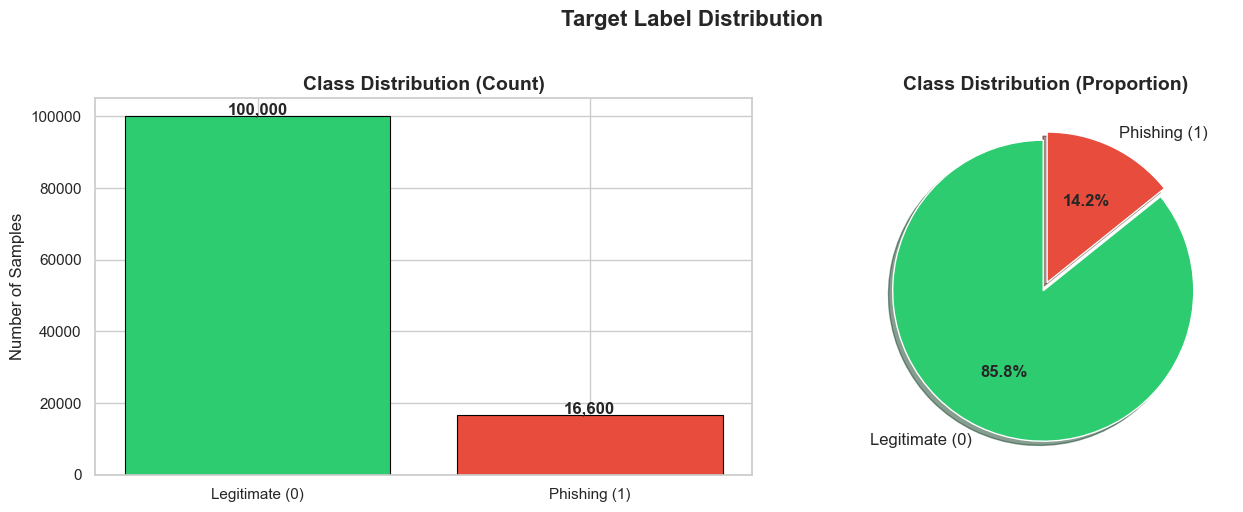

In [9]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
label_names = ['Legitimate (0)', 'Phishing (1)']

# Bar chart
axes[0].bar(label_names, label_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold', fontsize=12)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    label_counts.values, labels=label_names, autopct='%1.1f%%',
    colors=colors, startangle=90, explode=(0.03, 0.03),
    textprops={'fontsize': 12}, shadow=True
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1].set_title('Class Distribution (Proportion)', fontsize=14, fontweight='bold')

plt.suptitle('Target Label Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Skewness Analysis
Analyze how skewed each numerical feature is. Skewness > |1| is considered highly skewed.

In [10]:
# Compute skewness for all numerical columns (excluding 'url' and 'dom' which are text)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

skewness = df[numeric_cols].skew().sort_values(ascending=False)
skew_df = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values,
    'Abs Skewness': np.abs(skewness.values),
    'Category': pd.cut(np.abs(skewness.values),
                       bins=[-np.inf, 0.5, 1.0, np.inf],
                       labels=['Symmetric (<0.5)', 'Moderate (0.5-1.0)', 'Highly Skewed (>1.0)'])
})

print("=" * 55)
print("          FEATURE SKEWNESS SUMMARY")
print("=" * 55)
for cat in ['Highly Skewed (>1.0)', 'Moderate (0.5-1.0)', 'Symmetric (<0.5)']:
    subset = skew_df[skew_df['Category'] == cat]
    print(f"\n{cat}: {len(subset)} features")
    for _, row in subset.iterrows():
        print(f"   {row['Feature']:>20s} : {row['Skewness']:>8.3f}")
print("=" * 55)

          FEATURE SKEWNESS SUMMARY

Highly Skewed (>1.0): 19 features
                  is_ip :   94.691
              query_len :   37.279
            special_cnt :   28.566
              digit_cnt :   22.423
              under_cnt :   19.301
             letter_cnt :   16.067
                amp_cnt :   15.745
                url_len :   15.154
               path_len :   11.691
                 eq_cnt :   10.535
                 qm_cnt :    9.781
               dash_cnt :    5.901
            digit_ratio :    5.175
              slash_cnt :    3.162
                tld_len :    2.061
                  label :    2.047
                entropy :    1.577
                dom_len :    1.116
           letter_ratio :   -1.026

Moderate (0.5-1.0): 1 features
                dot_cnt :    0.976

Symmetric (<0.5): 3 features
               is_https :    0.278
             subdom_cnt :   -0.121
             spec_ratio :   -0.178


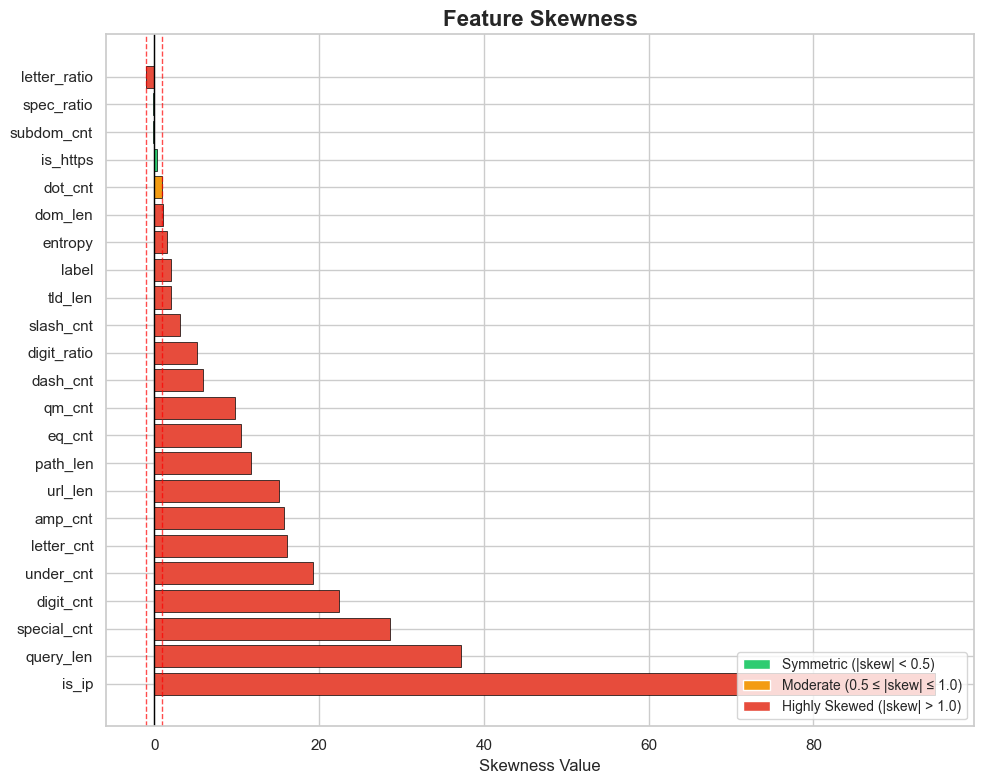

In [11]:
# Visualize skewness as a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))

colors_skew = ['#e74c3c' if abs(v) > 1 else '#f39c12' if abs(v) > 0.5 else '#2ecc71' for v in skewness.values]

ax.barh(skewness.index, skewness.values, color=colors_skew, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=1, color='red', linewidth=1, linestyle='--', alpha=0.7, label='Skew = 1')
ax.axvline(x=-1, color='red', linewidth=1, linestyle='--', alpha=0.7, label='Skew = -1')
ax.set_title('Feature Skewness', fontsize=16, fontweight='bold')
ax.set_xlabel('Skewness Value')
ax.legend(loc='lower right')

# Add color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Symmetric (|skew| < 0.5)'),
    Patch(facecolor='#f39c12', label='Moderate (0.5 ≤ |skew| ≤ 1.0)'),
    Patch(facecolor='#e74c3c', label='Highly Skewed (|skew| > 1.0)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## 5. Feature Distributions
Visualize distributions of key numerical features, split by class label.

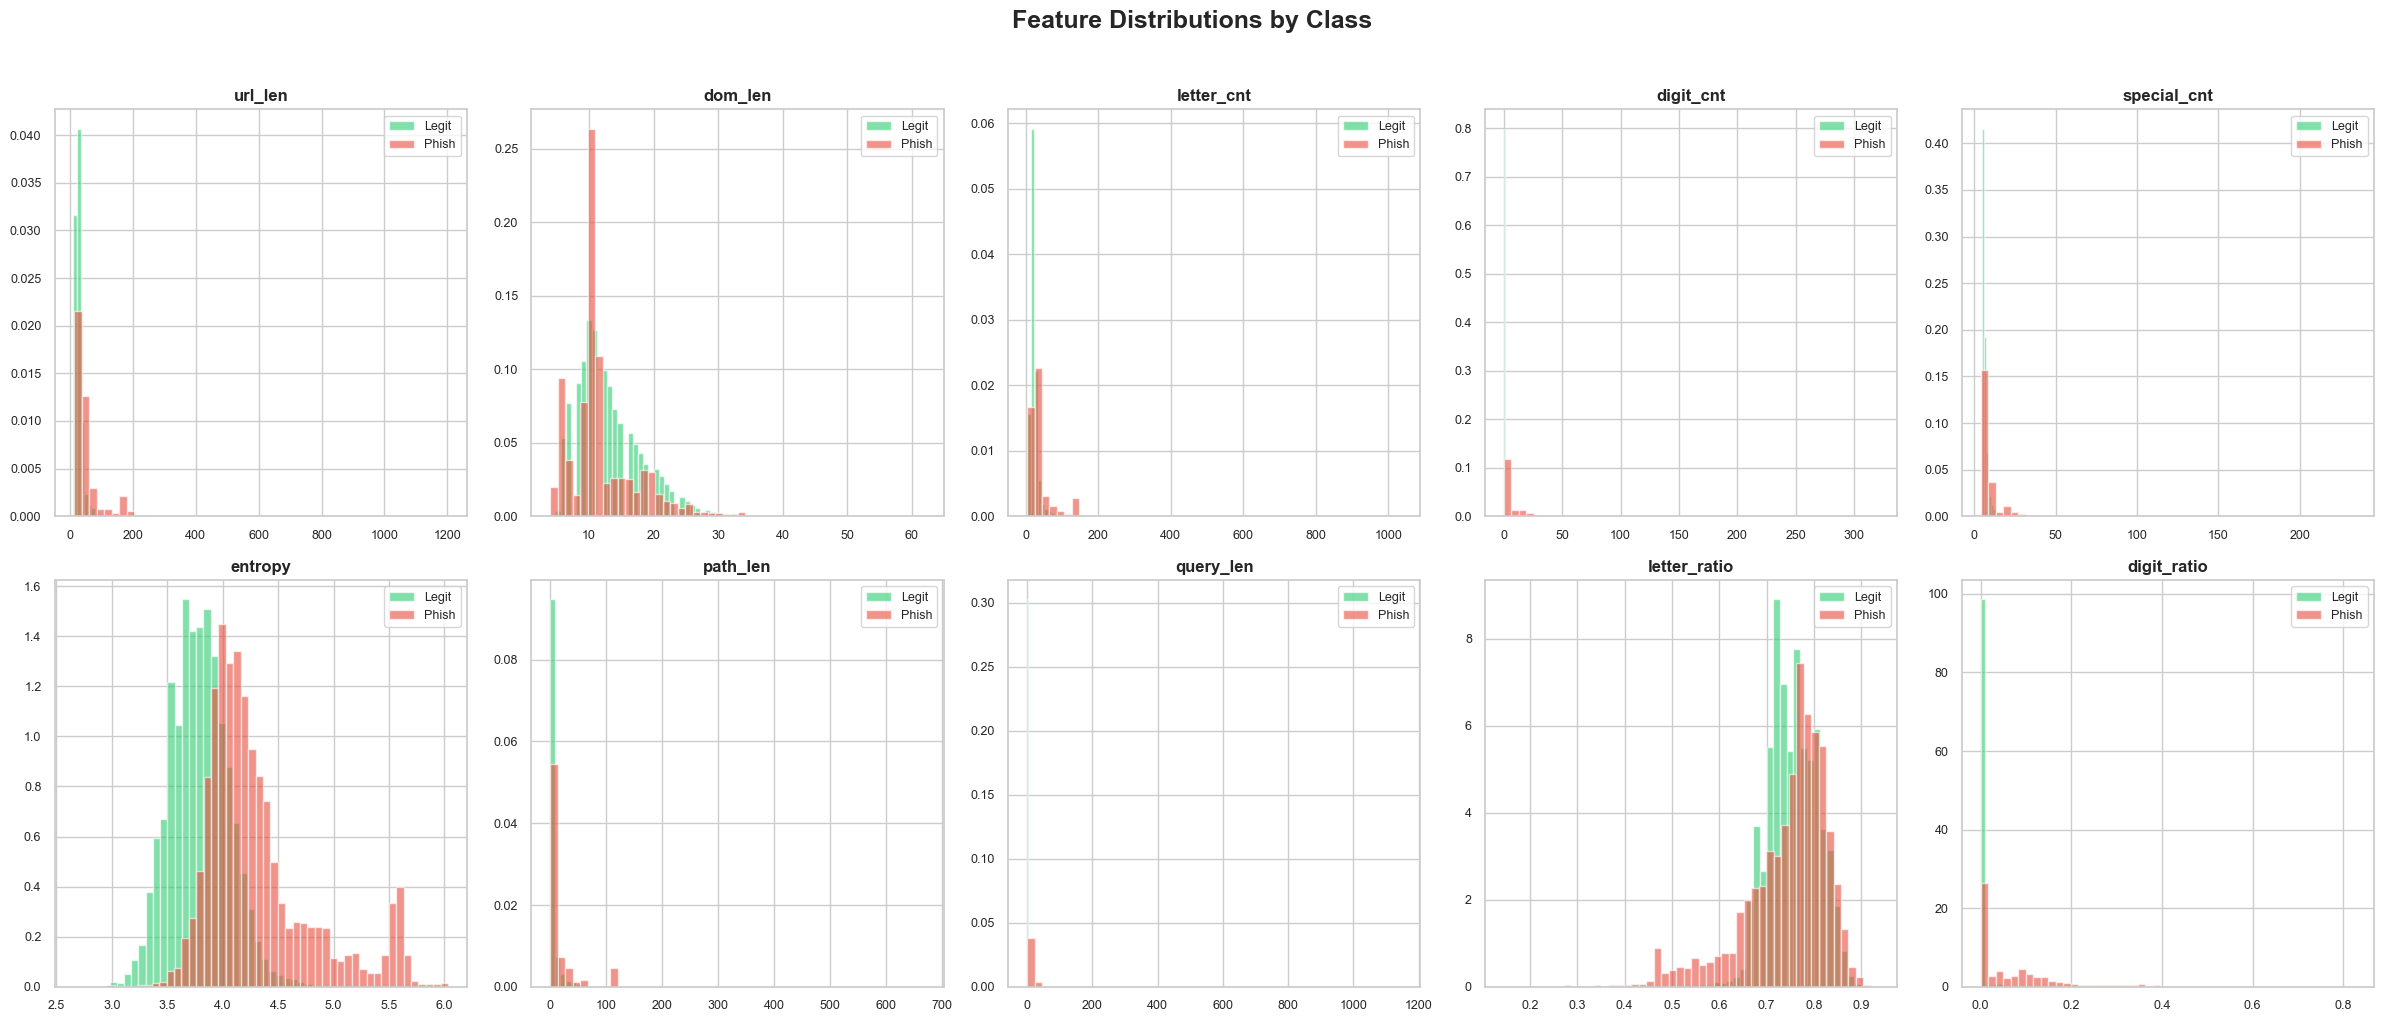

In [12]:
# Distribution plots for key features (split by label)
features_to_plot = ['url_len', 'dom_len', 'letter_cnt', 'digit_cnt', 'special_cnt',
                    'entropy', 'path_len', 'query_len', 'letter_ratio', 'digit_ratio']

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    for label_val, color, name in [(0, '#2ecc71', 'Legit'), (1, '#e74c3c', 'Phish')]:
        subset = df[df['label'] == label_val][col].dropna()
        axes[i].hist(subset, bins=50, alpha=0.6, label=name, color=color, density=True)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].tick_params(labelsize=9)

plt.suptitle('Feature Distributions by Class', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis
Check for multicollinearity and feature relationships.

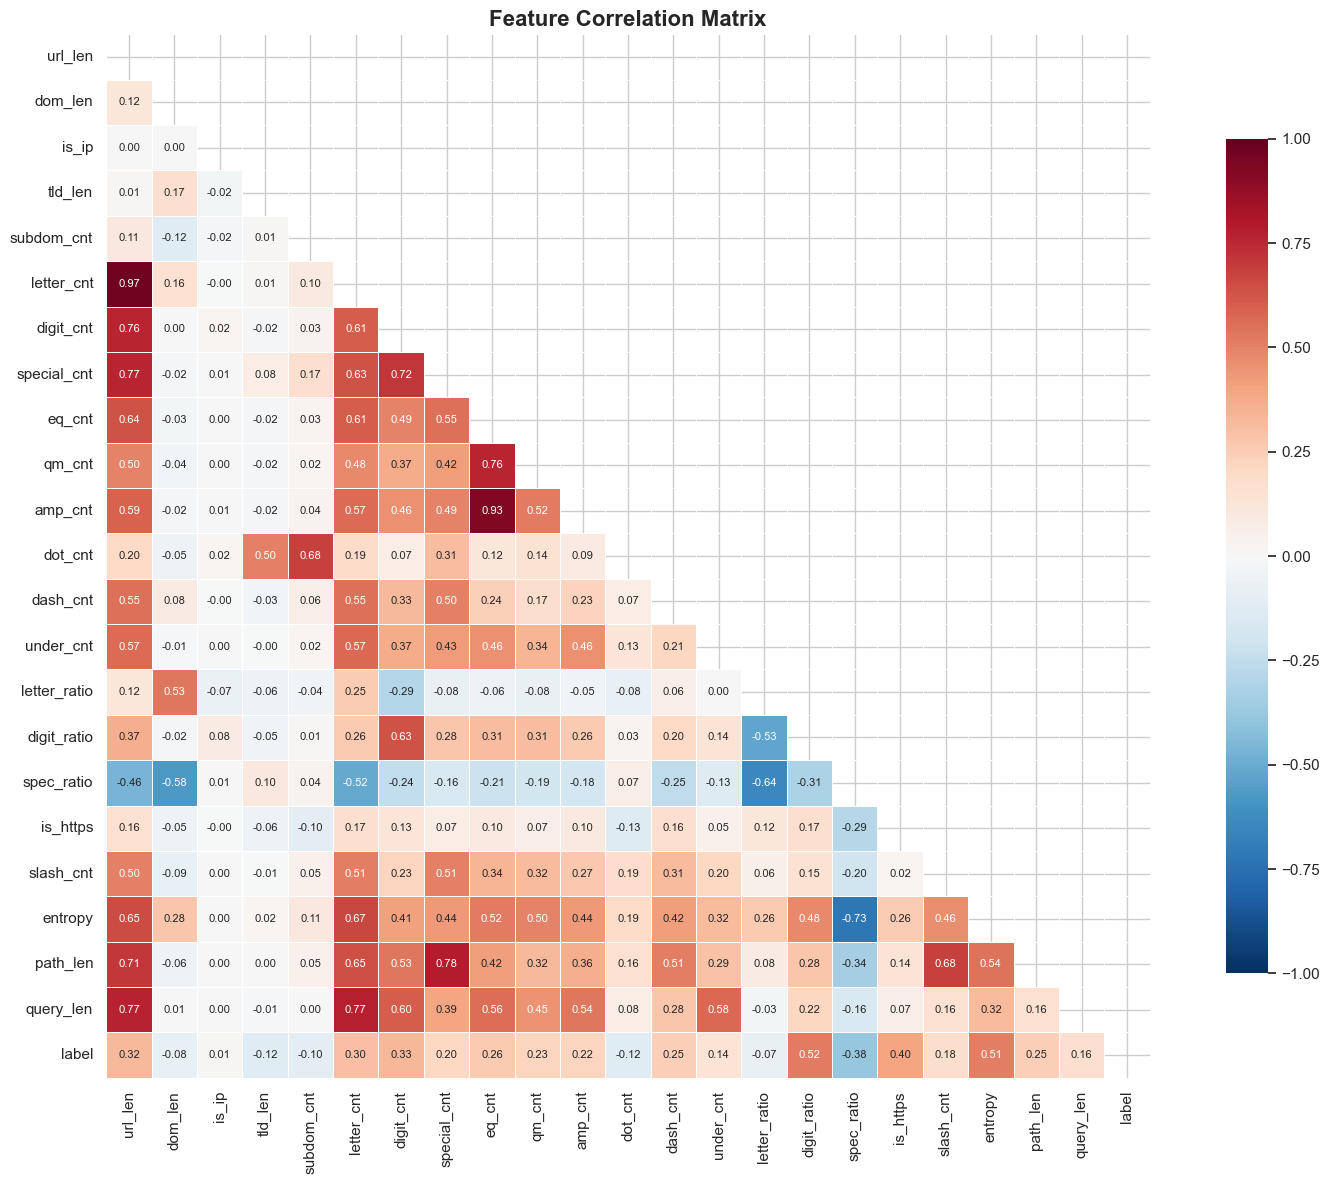

In [13]:
# Correlation heatmap
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 8})

ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Top correlated feature pairs (excluding self-correlation)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)

if len(high_corr_df) > 0:
    print(f"\n⚠️  Found {len(high_corr_df)} highly correlated feature pairs (|r| > 0.7):")
    print(high_corr_df.to_string(index=False))
else:
    print("✅ No highly correlated feature pairs found (|r| > 0.7).")


⚠️  Found 11 highly correlated feature pairs (|r| > 0.7):
  Feature 1   Feature 2  Correlation
    url_len  letter_cnt        0.972
     eq_cnt     amp_cnt        0.928
special_cnt    path_len        0.782
 letter_cnt   query_len        0.773
    url_len   query_len        0.766
    url_len special_cnt        0.765
    url_len   digit_cnt        0.764
     eq_cnt      qm_cnt        0.759
 spec_ratio     entropy       -0.726
  digit_cnt special_cnt        0.718
    url_len    path_len        0.708


## 7. Duplicate & Unique Value Check
Check for duplicate rows and unique value counts per feature.

In [15]:
# Duplicate rows check
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

# Unique value counts per column
print("\nUnique values per feature:")
print("-" * 35)
for col in df.columns:
    print(f"  {col:>18s}: {df[col].nunique():>8,}")

# Check for constant / near-constant features
print("\n--- Low-variance features (<=2 unique values) ---")
for col in df.columns:
    if df[col].nunique() <= 2:
        print(f"  {col}: {df[col].unique()}")

Duplicate rows: 1,369 (1.17%)

Unique values per feature:
-----------------------------------
                 url:  115,231
             url_len:      341
                 dom:   90,860
             dom_len:       47
               is_ip:        2
                 tld:    1,257
             tld_len:       22
          subdom_cnt:        7
          letter_cnt:      287
           digit_cnt:      129
         special_cnt:       75
              eq_cnt:       17
              qm_cnt:        5
             amp_cnt:       15
             dot_cnt:       13
            dash_cnt:       23
           under_cnt:       18
        letter_ratio:    1,750
         digit_ratio:    1,464
          spec_ratio:    1,106
            is_https:        2
           slash_cnt:       19
             entropy:   14,800
            path_len:      175
           query_len:      245
               label:        2

--- Low-variance features (<=2 unique values) ---
  is_ip: [0 1]
  is_https: [1 0]
  label: [0 1]


## 8. Outlier Detection (Box Plots)
Visualize outliers in key numerical features using box plots.

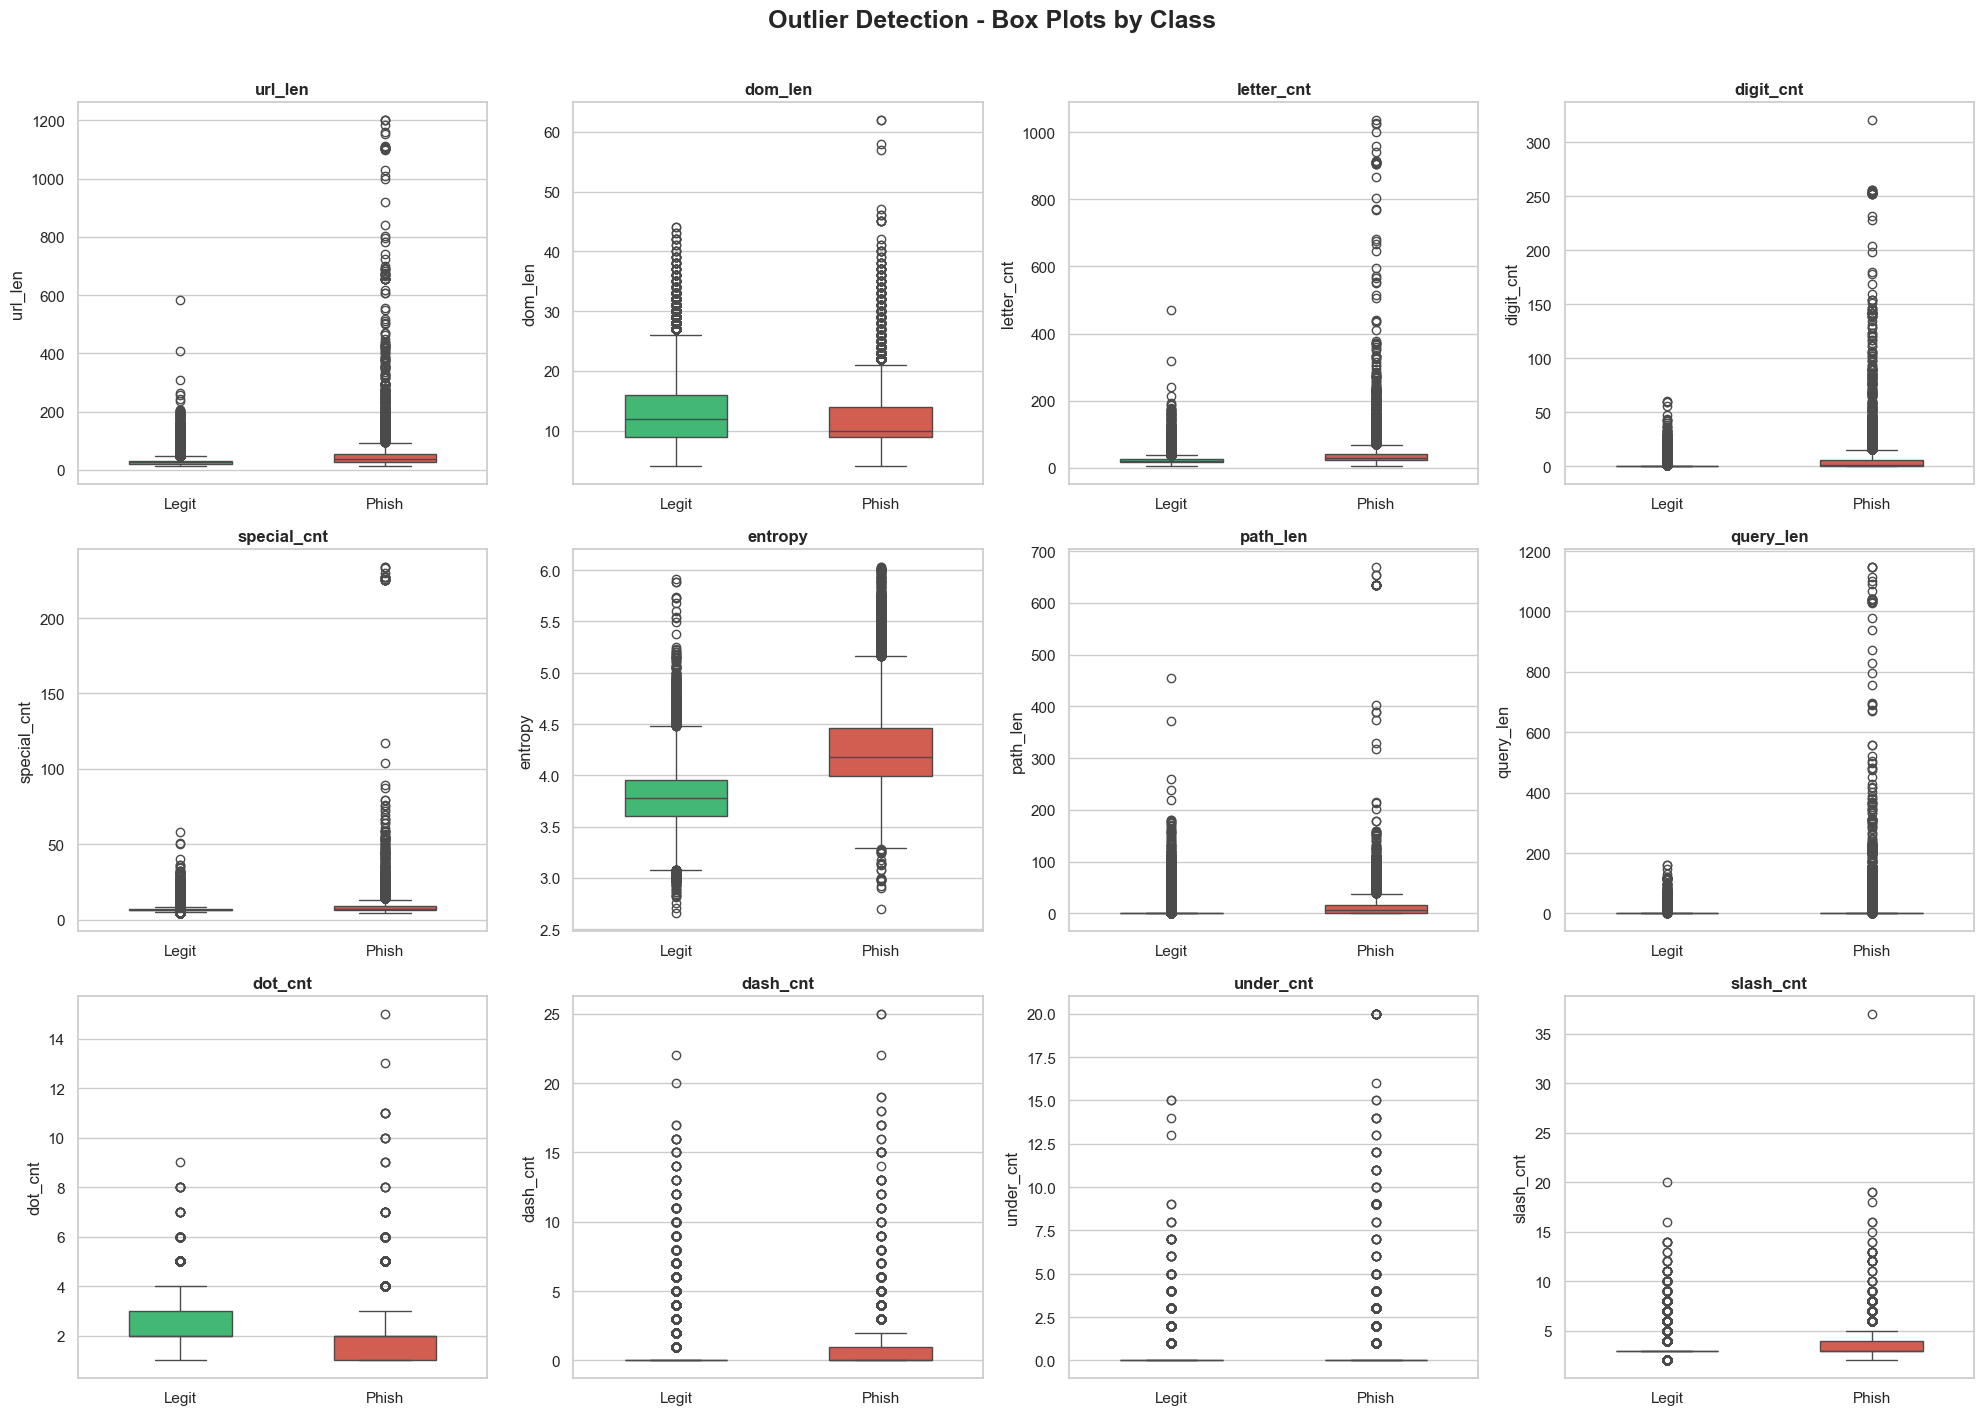

In [17]:
# Box plots for continuous features
continuous_features = ['url_len', 'dom_len', 'letter_cnt', 'digit_cnt',
                       'special_cnt', 'entropy', 'path_len', 'query_len',
                       'dot_cnt', 'dash_cnt', 'under_cnt', 'slash_cnt']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.boxplot(data=df, x='label', y=col, ax=axes[i],
                hue='label', palette=['#2ecc71', '#e74c3c'], width=0.5, legend=False)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(['Legit', 'Phish'])
    axes[i].set_xlabel('')

plt.suptitle('Outlier Detection - Box Plots by Class', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Outlier Percentage per Feature

Using IQR method (values outside Q1 - 1.5*IQR and Q3 + 1.5*IQR).

In [ ]:
# Outlier percentage for all numeric columns using IQR + class breakdown
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_stats = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_mask = (df[col] < lower) | (df[col] > upper)
    n_outliers = outlier_mask.sum()
    
    if n_outliers > 0:
        legit_out = (outlier_mask & (df['label'] == 0)).sum()
        phish_out = (outlier_mask & (df['label'] == 1)).sum()
        legit_pct = round(legit_out / n_outliers * 100, 1)
        phish_pct = round(phish_out / n_outliers * 100, 1)
    else:
        legit_pct = phish_pct = 0.0
    
    outlier_stats.append({
        'Feature': col,
        'Outliers': n_outliers,
        'Outlier %': round(n_outliers / len(df) * 100, 2),
        'Legit %': legit_pct,
        'Phish %': phish_pct,
    })

outlier_df = pd.DataFrame(outlier_stats).sort_values('Outlier %', ascending=False)
print(outlier_df.to_string(index=False))

     Feature  Outliers  Outlier %  Legit %  Phish %
   slash_cnt     34163      29.30     82.9     17.1
  subdom_cnt     28421      24.37     79.3     20.7
     tld_len     23655      20.29     97.9      2.1
    dash_cnt     22877      19.62     64.3     35.7
    path_len     20745      17.79     71.3     28.7
       label     16600      14.24      0.0    100.0
 special_cnt     16432      14.09     71.1     28.9
   digit_cnt     13824      11.86     31.8     68.2
 digit_ratio     13824      11.86     31.8     68.2
     url_len      9203       7.89     50.4     49.6
  letter_cnt      7777       6.67     55.2     44.8
      eq_cnt      4581       3.93     43.4     56.6
      qm_cnt      4421       3.79     45.3     54.7
   query_len      4417       3.79     45.3     54.7
     entropy      4077       3.50     17.1     82.9
   under_cnt      3212       2.75     54.0     46.0
     amp_cnt      2172       1.86     21.7     78.3
     dom_len      1994       1.71     81.7     18.3
letter_ratio

: 